# 03 — Model Training & Evaluation

**Requirement:** Run `02_preprocessing.ipynb` first

**Objective:** Train XGBoost / Random Forest / Logistic Regression, compare results, and select the best model

In [1]:
import sys; sys.path.append('..')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings('ignore')
from src.models import train_model, evaluate_model, compare_models
sns.set_theme(style='whitegrid')
print('Setup OK')

Setup OK


## 1. Load processed data

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (53475, 9) | Test: (44610, 9)


## 2. Train models

Models are configured in `src/models.py`. After training, they are automatically saved to the `models/` directory.

In [3]:
# XGBoost — usually performs best for tabular + imbalanced data
xgb = train_model('xgboost', X_train, y_train)

🚀 Training xgboost...
✅ Done!
   💾 Saved: d:\HUST\20252\T2 - Machine Learning\online-payment-fraud-detection\notebooks\..\src\..\models\xgboost.joblib


In [4]:
rf = train_model('random_forest', X_train, y_train)

🚀 Training random_forest...
✅ Done!
   💾 Saved: d:\HUST\20252\T2 - Machine Learning\online-payment-fraud-detection\notebooks\..\src\..\models\random_forest.joblib


In [5]:
# Logistic Regression — baseline for comparison
lr = train_model('logistic_regression', X_train, y_train)

🚀 Training logistic_regression...
✅ Done!
   💾 Saved: d:\HUST\20252\T2 - Machine Learning\online-payment-fraud-detection\notebooks\..\src\..\models\logistic_regression.joblib


## 3. Evaluate Each Model

Main metric: **PR-AUC (Average Precision)** — more reliable than ROC-AUC for imbalanced data

In fraud detection: prioritize **high Recall** (catch more fraud cases) + reasonable Precision (fewer false alarms)


EVALUATION: XGBOOST
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00     44563
       Fraud       0.12      0.96      0.22        47

    accuracy                           0.99     44610
   macro avg       0.56      0.98      0.61     44610
weighted avg       1.00      0.99      1.00     44610

ROC-AUC : 0.9889
PR-AUC  : 0.9139  ← preferred metric for imbalanced data
F1-Score: 0.2153
   📸 d:\HUST\20252\T2 - Machine Learning\online-payment-fraud-detection\notebooks\..\src\..\reports\figures\confusion_matrix_xgboost.png


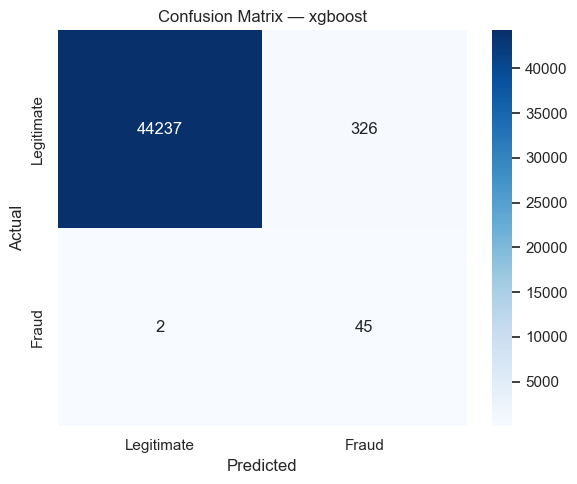

   📸 d:\HUST\20252\T2 - Machine Learning\online-payment-fraud-detection\notebooks\..\src\..\reports\figures\roc_pr_xgboost.png


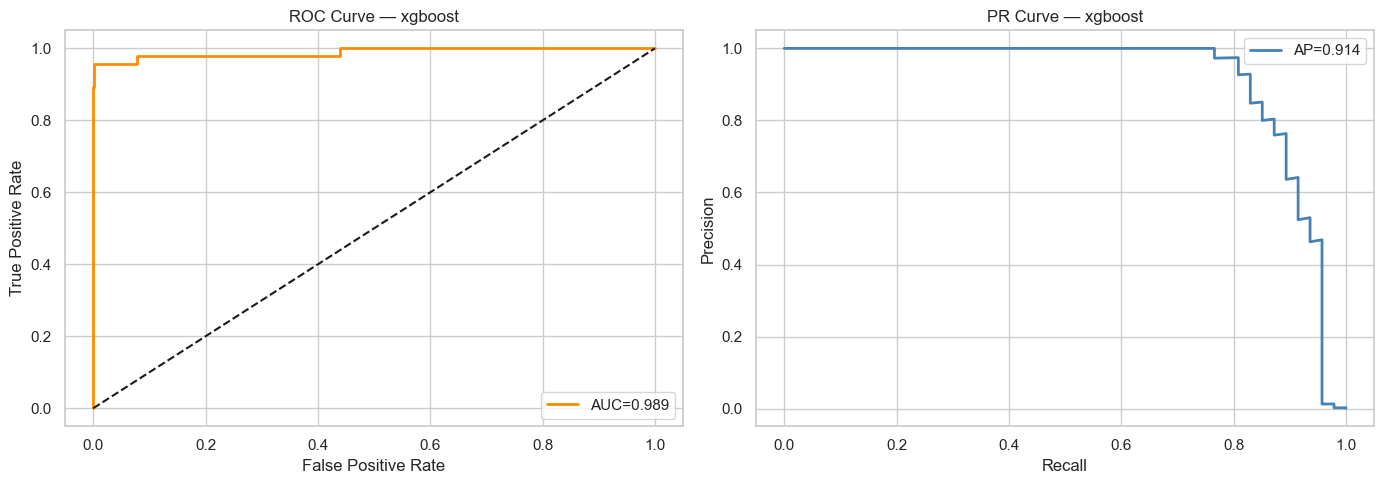

In [6]:
r_xgb = evaluate_model(xgb, X_test, y_test, 'xgboost')


EVALUATION: RANDOM_FOREST
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     44563
       Fraud       0.47      0.96      0.63        47

    accuracy                           1.00     44610
   macro avg       0.74      0.98      0.82     44610
weighted avg       1.00      1.00      1.00     44610

ROC-AUC : 0.9845
PR-AUC  : 0.9518  ← preferred metric for imbalanced data
F1-Score: 0.6338
   📸 d:\HUST\20252\T2 - Machine Learning\online-payment-fraud-detection\notebooks\..\src\..\reports\figures\confusion_matrix_random_forest.png


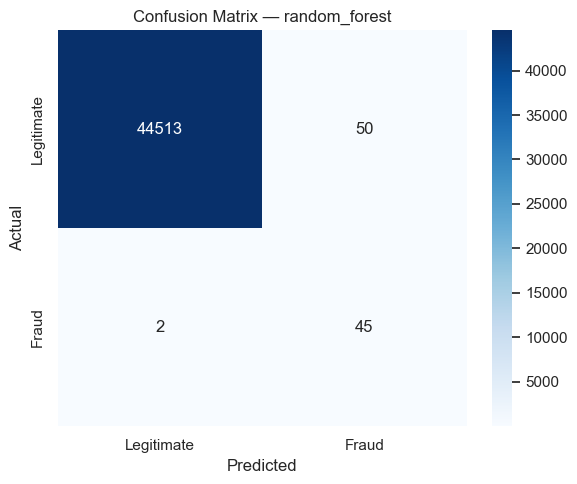

   📸 d:\HUST\20252\T2 - Machine Learning\online-payment-fraud-detection\notebooks\..\src\..\reports\figures\roc_pr_random_forest.png


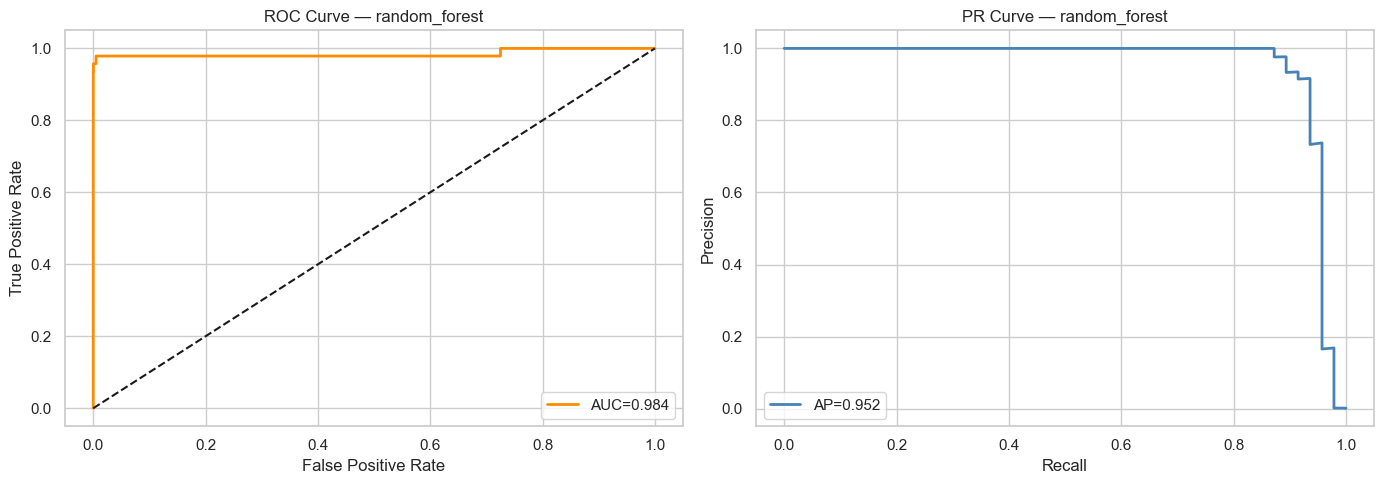

In [7]:
r_rf  = evaluate_model(rf,  X_test, y_test, 'random_forest')


EVALUATION: LOGISTIC_REGRESSION
              precision    recall  f1-score   support

  Legitimate       1.00      0.93      0.96     44563
       Fraud       0.01      0.83      0.03        47

    accuracy                           0.93     44610
   macro avg       0.51      0.88      0.50     44610
weighted avg       1.00      0.93      0.96     44610

ROC-AUC : 0.9416
PR-AUC  : 0.1834  ← preferred metric for imbalanced data
F1-Score: 0.0252
   📸 d:\HUST\20252\T2 - Machine Learning\online-payment-fraud-detection\notebooks\..\src\..\reports\figures\confusion_matrix_logistic_regression.png


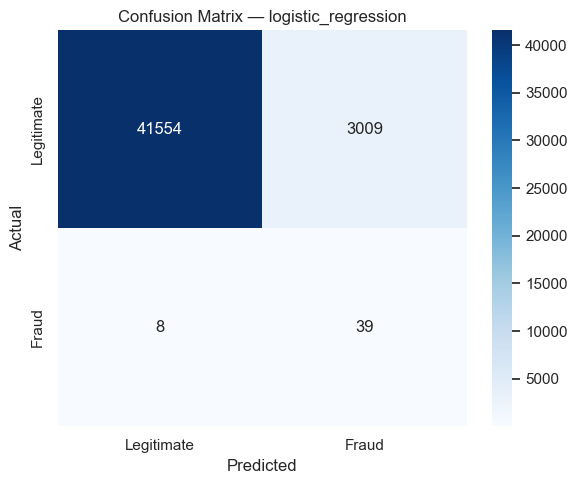

   📸 d:\HUST\20252\T2 - Machine Learning\online-payment-fraud-detection\notebooks\..\src\..\reports\figures\roc_pr_logistic_regression.png


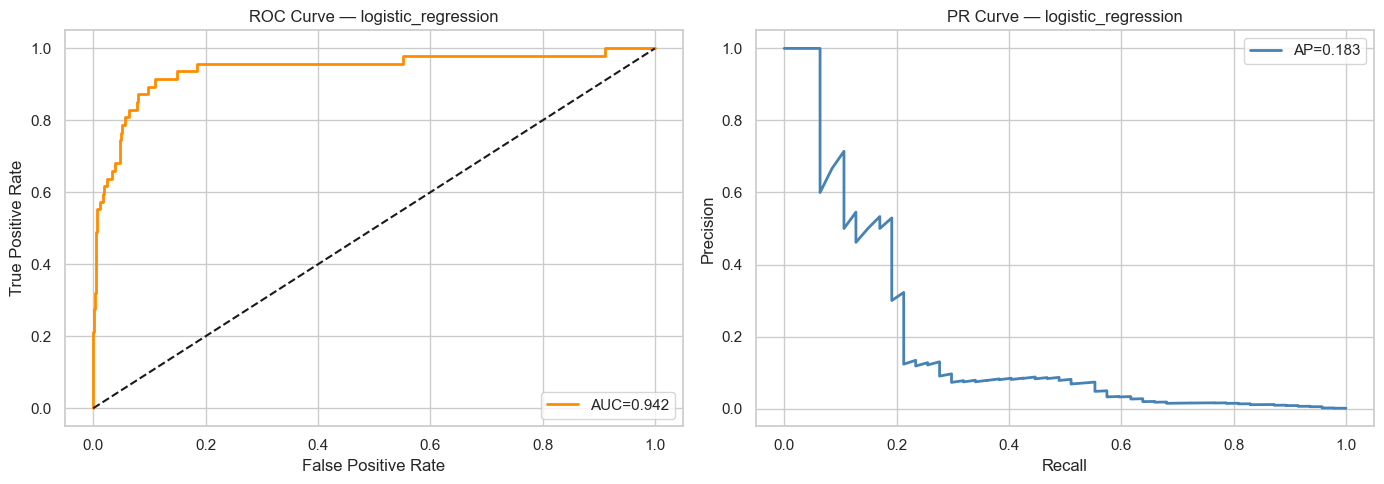

In [8]:
r_lr  = evaluate_model(lr,  X_test, y_test, 'logistic_regression')

## 4. Overall Comparison


📋 Model comparison:
                       roc_auc    pr_auc  f1_score
model_name                                       
random_forest        0.984455  0.951827  0.633803
xgboost              0.988910  0.913860  0.215311
logistic_regression  0.941599  0.183416  0.025202


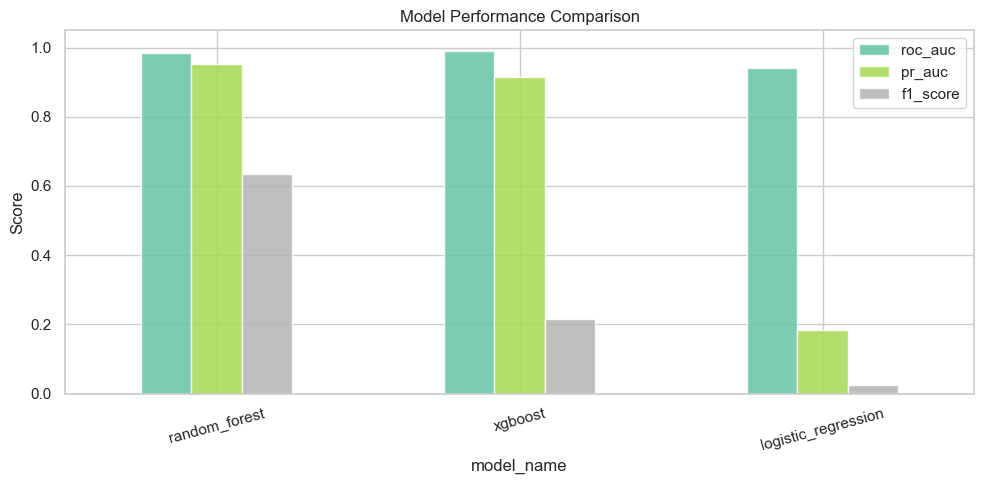

In [9]:
cmp = compare_models([r_xgb, r_rf, r_lr])

cmp[['roc_auc','pr_auc','f1_score']].plot(
    kind='bar', figsize=(10,5), colormap='Set2', alpha=0.85)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=150)
plt.show()

## 5. Feature Importance (XGBoost)

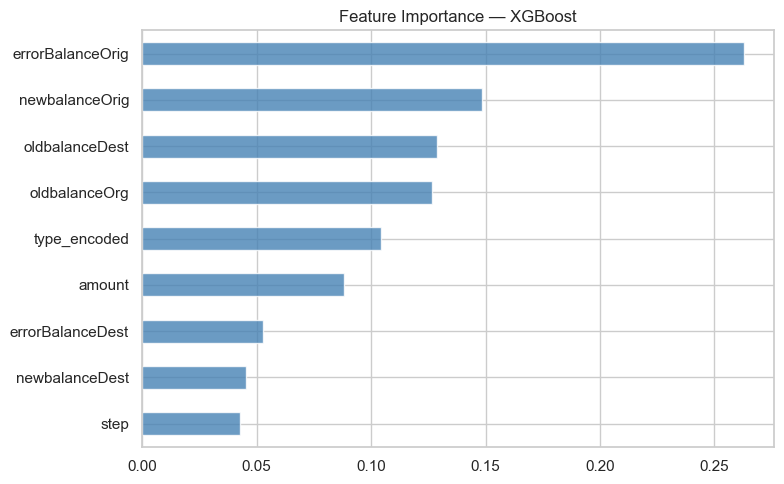

Top 3: oldbalanceDest      0.128916
newbalanceOrig      0.148501
errorBalanceOrig    0.262875


In [10]:
fi = pd.Series(xgb.feature_importances_,
               index=X_train.columns).sort_values(ascending=True)
fi.plot(kind='barh', figsize=(8,5), color='steelblue', alpha=0.8)
plt.title('Feature Importance — XGBoost')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=150)
plt.show()
print('Top 3:', fi.tail(3).to_string())

## 6. Conclusion

In [11]:
best = cmp['pr_auc'].idxmax()
print(f'Best model (PR-AUC): {best}')
print(cmp.loc[best].to_string())
print(f'Model saved: models/{best}.joblib')

Best model (PR-AUC): random_forest
roc_auc     0.984455
pr_auc      0.951827
f1_score    0.633803
Model saved: models/random_forest.joblib
